## We will simply use scikit learn's linear regression class and we will prepare our own multiple linear class and we will comapre the results from both if they will be same then we can say the algorithm works well for us,.

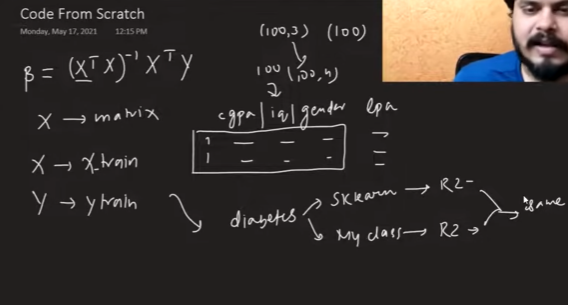

In [7]:
import numpy as np
from sklearn.datasets import load_diabetes  #pre-existing dataset in scikit learn

In [8]:
X,y = load_diabetes(return_X_y=True)

In [9]:
X


array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [10]:
y

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
        68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
        87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
       259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
       128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
       150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
       200., 252., 113., 143.,  51.,  52., 210.,  65., 141.,  55., 134.,
        42., 111.,  98., 164.,  48.,  96.,  90., 162., 150., 279.,  92.,
        83., 128., 102., 302., 198.,  95.,  53., 134., 144., 232.,  81.,
       104.,  59., 246., 297., 258., 229., 275., 281., 179., 200., 200.,
       173., 180.,  84., 121., 161.,  99., 109., 115., 268., 274., 158.,
       107.,  83., 103., 272.,  85., 280., 336., 281., 118., 317., 235.,
        60., 174., 259., 178., 128.,  96., 126., 28

In [15]:
y.shape
X.shape

(442, 10)

## Using sklearn's Linear Regression

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)


In [17]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [70]:
import numpy as np

# Demonstrate the shape of X_train after adding the intercept column
X_train_with_intercept = np.insert(X_train, 0, 1, axis=1)
print(f"Shape of X_train before adding intercept: {X_train.shape}")
print(f"Shape of X_train after adding intercept: {X_train_with_intercept.shape}")

Shape of X_train before adding intercept: (353, 10)
Shape of X_train after adding intercept: (353, 11)


In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
reg= LinearRegression()

In [61]:
reg.fit(X_train,y_train)

LinearRegression()

In [62]:
y_pred = reg.predict(X_test)

In [63]:
from sklearn.metrics import r2_score

In [64]:
r2_score(y_test,y_pred)

0.4399338661568968

In [65]:
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [66]:
reg.intercept_

np.float64(151.88331005254167)

## Making our own Regression Class

In [67]:
class MeraMLM:

  def __init__(self):
    self.coef_= None
    self.intercept_= None

  def fit(self,X_train,y_train):
    X_train= np.insert(X_train,0,1,axis= 1)   #np.insert(konse array me changes krne h,
    # konse index pr changes krne h,kya changes krne h, konsi axis pr change krna h)


     #calcultaing the coefficients (Beta0, beta1...betan)
    betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
    self.intercept_= betas[0]
    self.coef_= betas[1:]


  def predict( self,X_test):
    y_pred= np.dot(X_test,self.coef_)+self.intercept_
    return y_pred
    pass

In [68]:
lr = MeraMLM()

In [69]:
lr.fit(X_train, y_train)  # it prints exactly same as that of scikit's linear reg class' values


In [40]:
X_train

array([[-0.00188202, -0.04464164, -0.06979687, ..., -0.03949338,
        -0.06291688,  0.04034337],
       [-0.00914709, -0.04464164,  0.01103904, ..., -0.03949338,
         0.01703607, -0.0052198 ],
       [ 0.02354575,  0.05068012, -0.02021751, ..., -0.03949338,
        -0.09643495, -0.01764613],
       ...,
       [ 0.06350368,  0.05068012, -0.00405033, ..., -0.00259226,
         0.08449153, -0.01764613],
       [-0.05273755,  0.05068012, -0.01806189, ...,  0.1081111 ,
         0.03606033, -0.04249877],
       [ 0.00175052,  0.05068012,  0.05954058, ...,  0.1081111 ,
         0.06898589,  0.12732762]])

In [71]:
lr.predict(X_test)

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

In [72]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [73]:
lr.intercept_

np.float64(151.88331005254165)